In [19]:
import pandas as pd
import glob
import os

def load_stock_data(directory='../data'):
    """
    Загружает все CSV файлы из директории (исключая *_test.csv),
    нормализует их и объединяет в один DataFrame.
    """
    # 1. Получаем список всех csv файлов
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    
    # 2. Отфильтровываем те, что заканчиваются на _test.csv
    files_to_process = [f for f in all_files if not f.endswith('_test.csv') and not f.endswith('_train.csv')]
    
    if not files_to_process:
        print("Файлы для обработки не найдены.")
        return pd.DataFrame()

    all_data = []

    for file_path in files_to_process:
        # Извлекаем имя файла без расширения для колонки Symbol
        symbol = os.path.splitext(os.path.basename(file_path))[0]
        
        try:
            # Считываем данные
            df = pd.read_csv(file_path)
            
            # Приводим названия колонок к единому регистру на случай различий
            # (если в файле Close, а мы ищем close)
            df.columns = [c.capitalize() for c in df.columns]
            
            # Оставляем только нужные колонки
            required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
            
            # Проверяем наличие всех колонок
            if all(col in df.columns for col in required_columns):
                temp_df = df[required_columns].copy()
                temp_df['Symbol'] = symbol  # Добавляем колонку с тикером
                
                # Приводим дату к формату datetime для корректной сортировки
                temp_df['Date'] = pd.to_datetime(temp_df['Date'])
                
                all_data.append(temp_df)
            else:
                missing = [c for c in required_columns if c not in df.columns]
                print(f"В файле {symbol} отсутствуют колонки: {missing}")
                
        except Exception as e:
            print(f"Ошибка при чтении {file_path}: {e}")

    # 3. Объединяем все данные в один большой DF
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        # Сортируем для удобства по дате и символу
        final_df = final_df.sort_values(['Date', 'Symbol']).reset_index(drop=True)
        return final_df
    else:
        return pd.DataFrame()

In [20]:
df = load_stock_data()
df.head()

,Date,Open,High,Low,Close,Symbol
0,2014-02-06,18.216429,18.339287,18.136070,18.303928,AAPL
1,2014-02-06,60.700001,61.650002,60.650002,61.340000,ADBE
2,2014-02-06,3.320000,3.460000,3.320000,3.410000,AMD
3,2014-02-06,17.370001,17.740999,17.370001,17.729500,AMZN
4,2014-02-06,121.790001,122.720001,121.510002,122.669998,BA


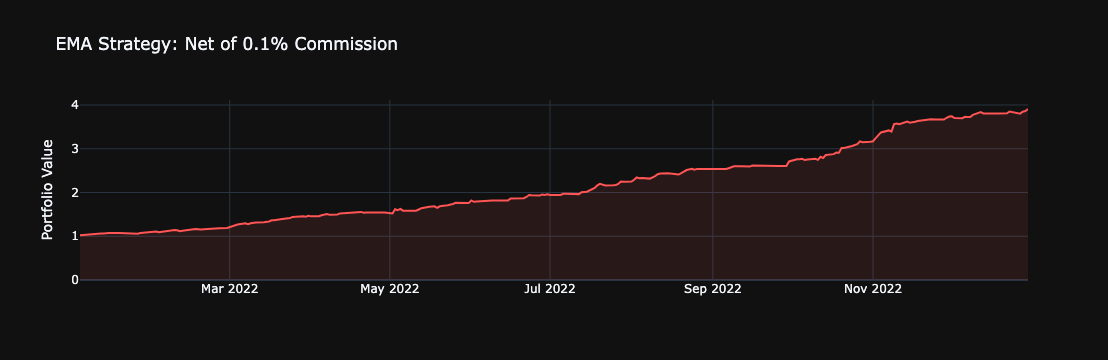

In [21]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def run_simulation_optimized(df, start_date, days=365, window=3, lookback=3, threshold=0.01, rebalance_days=1, commission=0.001):
    # 1. Setup Dates
    start_dt = pd.to_datetime(start_date)
    end_dt = start_dt + pd.Timedelta(days=days)
    
    # 2. Vectorized Pre-calculation
    prices_df = df.pivot(index='Date', columns='Symbol', values='Close').ffill().bfill()
    ema_df = prices_df.ewm(span=window, adjust=False).mean()
    ema_returns_df = ema_df.pct_change(periods=lookback)
    
    def has_extrema(x):
        if len(x) < 3: return False
        mid = x[1]
        return (mid > x[0] and mid > x[2]) or (mid < x[0] and mid < x[2])

    extrema_mask = ema_df.rolling(window=3, center=True).apply(has_extrema, raw=True)
    invalid_mask = extrema_mask.rolling(window=lookback-1).max().fillna(1.0).astype(bool)

    # 3. Filter Valid Signals
    valid_signals = ema_returns_df.where((ema_returns_df >= threshold) & (~invalid_mask), 0.0)
    
    row_sums = valid_signals.sum(axis=1)
    daily_weights = valid_signals.div(row_sums, axis=0).fillna(0.0)
    #print(daily_weights)

    # 4. Apply Rebalance Interval
    rebalance_indices = np.arange(len(daily_weights)) % rebalance_days == 0
    weights_df = daily_weights.copy()
    weights_df[~rebalance_indices] = np.nan
    weights_df = weights_df.ffill().fillna(0.0)

    # 5. Slicing for Simulation
    sim_weights = weights_df.loc[start_dt:end_dt]
    active_row_sums = sim_weights.sum(axis=1)
    
    # Calculate Turnover for Commission
    # turnover = sum of absolute change in weights for each asset
    weight_changes = sim_weights.diff().abs().sum(axis=1)
    # Handle the first day: the initial buy-in is also turnover
    weight_changes.iloc[0] = sim_weights.iloc[0].sum()
    
    commission_costs = weight_changes * commission
    
    # 6. Performance Calculation
    price_returns_factor = prices_df.pct_change().shift(-1).loc[start_dt:end_dt] + 1
    
    # Raw Daily Growth
    daily_growth = (sim_weights * price_returns_factor).sum(axis=1)
    
    # Apply Commission (subtracted from the growth factor)
    net_growth = daily_growth - commission_costs
    
    # Handle days with no signals (Hold Cash = 1.0 growth, but costs still apply if we just exited)
    net_growth = net_growth.mask(active_row_sums == 0, 1.0 - commission_costs)
    
    # Cumulative Value
    value_curve = net_growth.cumprod()

    # 7. Plotting
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=value_curve.index, 
        y=value_curve.values,
        fill='tozeroy',
        name=f'Net Value (Comm: {commission*100}%)',
        line=dict(color='#FF5555', width=2), # Red to indicate costs are included
        fillcolor='rgba(255, 85, 85, 0.1)'
    ))

    fig.update_layout(
        template="plotly_dark",
        title=f"EMA Strategy: Net of {commission*100}% Commission",
        yaxis_title="Portfolio Value",
        hovermode="x unified"
    )
    fig.show()

    return value_curve

# Usage:
value_history = run_simulation_optimized(df, '2022-01-01', commission=0.001)


=========================== EXECUTED ORDERS LOG ===========================

📅 Date: 2022-01-03 | Portfolio Value: $10,248.63
   🟢 BUY  IBM   | Weight: +50.96% | Value: +$5,222.77 | Price: $136.04
   🟢 BUY  XOM   | Weight: +49.04% | Value: +$5,025.85 | Price: $63.54
   💵 Free Cash Remaining: $0.00

📅 Date: 2022-01-04 | Portfolio Value: $10,308.75
   🔴 SELL IBM   | Weight: -37.14% | Value: -$3,828.84 | P&L: +1.46%
   🔴 SELL XOM   | Weight: -19.90% | Value: -$2,051.47 | P&L: +3.76%
   🟢 BUY  BA    | Weight: +17.23% | Value: +$1,776.21 | Price: $213.63
   🟢 BUY  CAT   | Weight: +17.18% | Value: +$1,771.52 | Price: $218.08
   🟢 BUY  CVX   | Weight: +10.92% | Value: +$1,125.45 | Price: $121.43
   🟢 BUY  INTC  | Weight: +11.71% | Value: +$1,207.13 | Price: $53.14
   💵 Free Cash Remaining: $0.00

📅 Date: 2022-01-05 | Portfolio Value: $10,383.32
   🔴 SELL BA    | Weight: -0.52% | Value: -$   53.54 | P&L: -0.26%
   🔴 SELL IBM   | Weight: -13.82% | Value: -$1,434.88 | P&L: +1.60%
   🔴 SELL XOM 

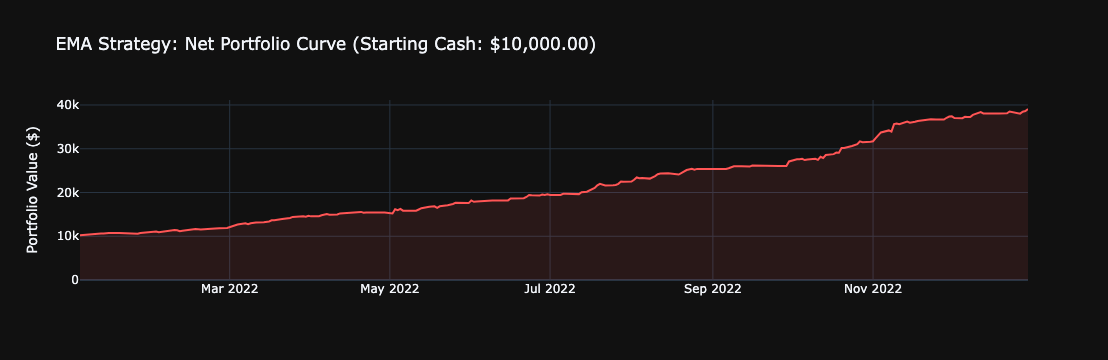

In [22]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def run_simulation_optimized(df, start_date, days=365, window=3, lookback=3, threshold=0.01, 
                             rebalance_days=1, initial_capital=10000.0, commission=0.001):
    # 1. Setup Dates
    start_dt = pd.to_datetime(start_date)
    end_dt = start_dt + pd.Timedelta(days=days)
    
    # 2. Vectorized Pre-calculation
    prices_df = df.pivot(index='Date', columns='Symbol', values='Close').ffill().bfill()
    prices_df.index = pd.to_datetime(prices_df.index)
    
    ema_df = prices_df.ewm(span=window, adjust=False).mean()
    ema_returns_df = ema_df.pct_change(periods=lookback)
    
    def has_extrema(x):
        if len(x) < 3: return False
        mid = x[1]
        return (mid > x[0] and mid > x[2]) or (mid < x[0] and mid < x[2])

    extrema_mask = ema_df.rolling(window=3, center=True).apply(has_extrema, raw=True)
    invalid_mask = extrema_mask.rolling(window=lookback-1).max().fillna(1.0).astype(bool)

    # 3. Filter Valid Signals
    valid_signals = ema_returns_df.where((ema_returns_df >= threshold) & (~invalid_mask), 0.0)
    
    row_sums = valid_signals.sum(axis=1)
    daily_weights = valid_signals.div(row_sums, axis=0).fillna(0.0)

    # 4. Apply Rebalance Interval
    rebalance_indices = np.arange(len(daily_weights)) % rebalance_days == 0
    weights_df = daily_weights.copy()
    weights_df[~rebalance_indices] = np.nan
    weights_df = weights_df.ffill().fillna(0.0)

    # 5. Slicing for Simulation
    sim_weights = weights_df.loc[start_dt:end_dt]
    sim_prices = prices_df.loc[start_dt:end_dt]
    active_row_sums = sim_weights.sum(axis=1)
    
    # Calculate Weight Changes Matrix
    weight_changes_df = sim_weights.diff()
    weight_changes_df.iloc[0] = sim_weights.iloc[0]
    
    weight_changes = weight_changes_df.abs().sum(axis=1)
    commission_costs = weight_changes * commission
    
    # 6. Performance & Growth Setup (to track current portfolio value for dollar sizing)
    price_returns_factor = prices_df.pct_change().shift(-1).loc[start_dt:end_dt] + 1
    daily_growth = (sim_weights * price_returns_factor).sum(axis=1)
    net_growth = daily_growth - commission_costs
    net_growth = net_growth.mask(active_row_sums == 0, 1.0 - commission_costs)
    
    # Generate cumulative running value of the portfolio
    value_curve = initial_capital * net_growth.cumprod()

    # -------------------------------------------------------------
    # TRACK COST BASIS, DOLLAR CASH, AND PRINT LOGS
    # -------------------------------------------------------------
    print(f"\n=========================== EXECUTED ORDERS LOG ===========================")
    symbols = sim_weights.columns.tolist()
    
    cost_basis = {symbol: 0.0 for symbol in symbols}
    active_weights = {symbol: 0.0 for symbol in symbols}
    running_cash = initial_capital

    for date, rows in weight_changes_df.iterrows():
        # Check if any rebalance occurred today
        if (rows.abs() > 1e-6).any():
            current_portfolio_value = value_curve.loc[date]
            print(f"\n📅 Date: {date.strftime('%Y-%m-%d')} | Portfolio Value: ${current_portfolio_value:,.2f}")
            
            # 1. Process SELLS first to release cash back into the pool
            for symbol in symbols:
                w_change = rows[symbol]
                if w_change < -1e-6:
                    target_w = sim_weights.loc[date, symbol]
                    current_price = sim_prices.loc[date, symbol]
                    
                    # Size of trade based on overall portfolio equity
                    trade_dollar_value = abs(w_change) * current_portfolio_value
                    trade_commission = trade_dollar_value * commission
                    
                    # Cash increases by trade value minus commission cost
                    running_cash += (trade_dollar_value - trade_commission)
                    
                    # Calculate realized performance
                    entry_p = cost_basis[symbol]
                    profit_str = f"{((current_price - entry_p) / entry_p) * 100:+.2f}%" if entry_p > 0 else "0.00%"
                    
                    print(f"   🔴 SELL {symbol:5s} | Weight: {w_change:6.2%} | Value: -${trade_dollar_value:8,.2f} | P&L: {profit_str}")
                    
                    active_weights[symbol] = target_w
                    if target_w < 1e-6:
                        cost_basis[symbol] = 0.0

            # 2. Process BUYS next using the available cash pool
            for symbol in symbols:
                w_change = rows[symbol]
                if w_change > 1e-6:
                    target_w = sim_weights.loc[date, symbol]
                    current_price = sim_prices.loc[date, symbol]
                    
                    trade_dollar_value = w_change * current_portfolio_value
                    trade_commission = trade_dollar_value * commission
                    
                    # Cash decreases by trade value plus commission cost
                    running_cash -= (trade_dollar_value + trade_commission)
                    
                    # Adjust moving cost basis
                    prev_w = active_weights[symbol]
                    total_w = prev_w + w_change
                    cost_basis[symbol] = (((prev_w * cost_basis[symbol]) + (w_change * current_price)) / total_w) if total_w > 0 else current_price
                    
                    print(f"   🟢 BUY  {symbol:5s} | Weight: +{w_change:5.2%} | Value: +${trade_dollar_value:8,.2f} | Price: ${current_price:,.2f}")
                    active_weights[symbol] = target_w
            
            # Print remaining free cash at the end of the day's operations
            # (Enforcing a floor of 0 for slight floating-point mismatches when 100% allocated)
            running_cash = max(0.0, running_cash)
            print(f"   💵 Free Cash Remaining: ${running_cash:,.2f}")

    print(f"===========================================================================\n")
    # -------------------------------------------------------------
    
    # 7. Plotting
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=value_curve.index, 
        y=value_curve.values,
        fill='tozeroy',
        name=f'Net Portfolio Value',
        line=dict(color='#FF5555', width=2),
        fillcolor='rgba(255, 85, 85, 0.1)'
    ))

    fig.update_layout(
        template="plotly_dark",
        title=f"EMA Strategy: Net Portfolio Curve (Starting Cash: ${initial_capital:,.2f})",
        yaxis_title="Portfolio Value ($)",
        hovermode="x unified"
    )
    fig.show()

    return value_curve

value_history = run_simulation_optimized(df, '2022-01-01', commission=0.001)